# 1. Analyse Exploratoire des Données (EDA)

**Projet Semesteriel - Détection de Fake News COVID-19**  
**Niveau 4CS | Superviseur : Prof. Salem Trabelsi**

---

## Objectif

Ce notebook a pour but d'explorer et de comprendre le jeu de données COVID-19 Fake News Dataset (Kaggle).  
Le dataset contient environ **10 700 posts/articles** classés en deux catégories : **fake** (faux) et **real** (éels).

Nous allons analyser :
- La distribution des classes
- Les caractéristiques textuelles (longueur, fréquence des mots)
- Les mots les plus fréquents par classe
- Les nuages de mots
- Les bigrammes et trigrammes
- Les valeurs manquantes
- Des tests statistiques

## 1.1 Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Télécharger les ressources NLTK nécessaires
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 1.2 Chargement du jeu de données

Le dataset est stocké dans le dossier `../data/raw/`.  
Nous essayons plusieurs noms de fichiers courants utilisés dans le dataset Kaggle COVID-19 Fake News.

In [2]:
import os

RAW_DATA_DIR = os.path.join('..', 'data', 'raw')

# Fichiers possibles du dataset Constraint (COVID-19 Fake News)
possible_files = {
    'train': ['Constraint_Train.csv', 'train.csv', 'covid_fake_news_train.csv'],
    'val': ['Constraint_Val.csv', 'val.csv', 'covid_fake_news_val.csv'],
    'test': ['Constraint_Test.csv', 'test.csv', 'covid_fake_news_test.csv'],
    'full': ['covid_fake_news.csv', 'data.csv', 'dataset.csv', 'fake_news_covid.csv']
}

dataframes = {}

In [3]:
# Lister tous les fichiers disponibles
if os.path.exists(RAW_DATA_DIR):
    available_files = os.listdir(RAW_DATA_DIR)
    print(f"Fichiers disponibles dans {RAW_DATA_DIR}: {available_files}")
else:
    available_files = []
    print(f"Le dossier {RAW_DATA_DIR} n\'existe pas.")

Fichiers disponibles dans ..\data\raw: ['Constraint_Test.csv', 'Constraint_Train.csv', 'Constraint_Val.csv']


In [4]:
# Charger les fichiers trouves
for split, filenames in possible_files.items():
    for fname in filenames:
        fpath = os.path.join(RAW_DATA_DIR, fname)
        if os.path.exists(fpath):
            dataframes[split] = pd.read_csv(fpath)
            print(f"\n[OK] {split}: {fname} charge ({dataframes[split].shape[0]} lignes, {dataframes[split].shape[1]} colonnes)")
            break


[OK] train: Constraint_Train.csv charge (6420 lignes, 3 colonnes)

[OK] val: Constraint_Val.csv charge (2140 lignes, 3 colonnes)

[OK] test: Constraint_Test.csv charge (2140 lignes, 2 colonnes)


In [5]:
# Combiner train/val uniquement (test n'a pas de labels dans ce dataset)
if 'full' in dataframes:
    df = dataframes['full'].copy()
    print(f"\nDataset complet charge : {df.shape}")
elif 'train' in dataframes:
    # Ne pas inclure test car il n'a pas de colonne label
    dfs_to_concat = [dataframes[s] for s in ['train', 'val'] if s in dataframes]
    df = pd.concat(dfs_to_concat, ignore_index=True)
    print(f"\nDataset combine (train+val) : {df.shape}")
else:
    csv_files = [f for f in available_files if f.endswith('.csv')]
    if csv_files:
        df = pd.read_csv(os.path.join(RAW_DATA_DIR, csv_files[0]))
        print(f"\nFichier charge par defaut : {csv_files[0]} ({df.shape})")
    else:
        raise FileNotFoundError(f"Aucun fichier CSV trouve dans {RAW_DATA_DIR}.")


Dataset combine (train+val) : (8560, 3)


In [6]:
# Supprimer les lignes sans label (au cas ou)
label_candidates = ['label', 'class', 'target', 'category']
for col in df.columns:
    if col.lower() in label_candidates:
        df = df.dropna(subset=[col])
        break

print(f"\nDataset final : {df.shape[0]} lignes, {df.shape[1]} colonnes")


Dataset final : 8560 lignes, 3 colonnes


## 1.3 Informations de base sur le dataset

In [7]:
# Identifier les colonnes de texte et de label
print("=" * 60)
print("COLONNES DU DATASET")
print("=" * 60)
print(f"Colonnes : {list(df.columns)}")
print(f"\nTypes de données :")
print(df.dtypes)

COLONNES DU DATASET
Colonnes : ['id', 'tweet', 'label']

Types de données :
id        int64
tweet    object
label    object
dtype: object


In [8]:
# Détecter automatiquement les colonnes clés
text_col = None
label_col = None

for col in df.columns:
    col_lower = col.lower()
    if col_lower in ['tweet', 'text', 'content', 'news', 'article', 'sentence']:
        text_col = col
    if col_lower in ['label', 'class', 'target', 'category', 'fake']:
        label_col = col

if text_col is None:
    # Prendre la colonne avec le plus de texte
    str_cols = df.select_dtypes(include='object').columns
    if len(str_cols) > 0:
        text_col = str_cols[df[str_cols].apply(lambda x: x.str.len().mean()).idxmax()]

if label_col is None:
    # Prendre la colonne avec le moins de valeurs uniques
    for col in df.columns:
        if df[col].nunique() <= 5 and col != text_col:
            label_col = col
            break

In [9]:
print(f"\nColonne de texte détectée : '{text_col}'")
print(f"Colonne de label détectée : '{label_col}'")


Colonne de texte détectée : 'tweet'
Colonne de label détectée : 'label'


In [10]:
# Aperçu des données
print("=" * 60)
print("APERÇU DU DATASET")
print("=" * 60)
df.head(10)

APERÇU DU DATASET


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In gen...,real
1,2,States reported 1121 deaths a small rise from ...,real
2,3,Politically Correct Woman (Almost) Uses Pandem...,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testin...,real
4,5,Populous states can generate large case counts...,real
5,6,"Covid Act Now found ""on average each person in...",real
6,7,If you tested positive for #COVID19 and have n...,real
7,8,Obama Calls Trump’s Coronavirus Response A Cha...,fake
8,9,"???Clearly, the Obama administration did not l...",fake
9,10,Retraction—Hydroxychloroquine or chloroquine w...,fake


In [11]:
# Statistiques descriptives
print("=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
print(f"Forme du dataset : {df.shape}")
print(f"Nombre de données : {len(df)}")
print()
df.describe(include='all')

STATISTIQUES DESCRIPTIVES
Forme du dataset : (8560, 3)
Nombre de données : 8560



,id,tweet,label
count,8560.000000,8560,8560
unique,NaN,8559,2
top,NaN,Our combined total of confirmed and probable c...,real
freq,NaN,2,4480
mean,2675.500000,NaN,NaN
std,1878.967986,NaN,NaN
min,1.000000,NaN,NaN
25%,1070.750000,NaN,NaN
50%,2140.500000,NaN,NaN
75%,4280.250000,NaN,NaN


## 1.4 Analyse des valeurs manquantes

In [12]:
# Analyse des valeurs manquantes
print("=" * 60)
print("VALEURS MANQUANTES")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct.round(2)
})
print(missing_df)

# Vérifier les doublons
duplicates = df.duplicated().sum()
print(f"\nNombre de lignes dupliquées : {duplicates} ({duplicates/len(df)*100:.2f}%)")

# Vérifier les textes vides
if text_col:
    empty_texts = df[text_col].apply(lambda x: len(str(x).strip()) == 0).sum()
    print(f"Textes vides : {empty_texts}")

VALEURS MANQUANTES
       Valeurs manquantes  Pourcentage (%)
id                      0              0.0
tweet                   0              0.0
label                   0              0.0

Nombre de lignes dupliquées : 0 (0.00%)
Textes vides : 0


In [13]:
# Visualisation des valeurs manquantes
if missing.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing[missing > 0].plot(kind='bar', color='coral', ax=ax)
    ax.set_title('Valeurs manquantes par colonne', fontsize=14, fontweight='bold')
    ax.set_ylabel('Nombre de valeurs manquantes')
    ax.set_xlabel('Colonnes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune valeur manquante dans le dataset.")

Aucune valeur manquante dans le dataset.


## 1.5 Distribution des classes

Analysons l'équilibre entre les classes **fake** et **real** dans le dataset.

In [14]:
# Distribution des classes
print("=" * 60)
print("DISTRIBUTION DES CLASSES")
print("=" * 60)

class_dist = df[label_col].value_counts()
class_pct = df[label_col].value_counts(normalize=True) * 100

print("Comptage :")
print(class_dist)
print(f"\nPourcentage :")
for cls, pct in class_pct.items():
    print(f"  {cls}: {pct:.1f}%")

DISTRIBUTION DES CLASSES
Comptage :
label
real    4480
fake    4080
Name: count, dtype: int64

Pourcentage :
  real: 52.3%
  fake: 47.7%


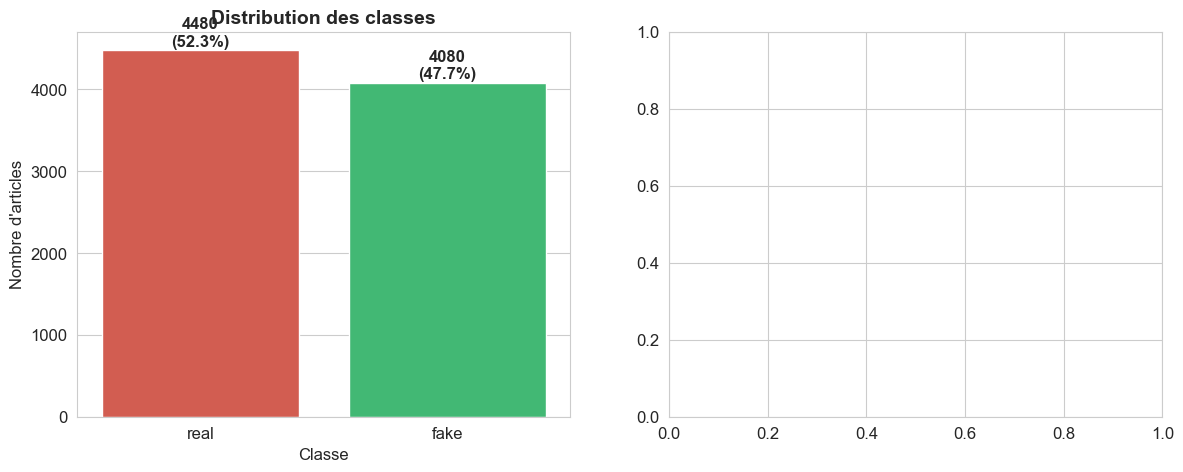

In [15]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colors = ['#e74c3c', '#2ecc71']  # rouge pour fake, vert pour real
sns.countplot(data=df, x=label_col, palette=colors, ax=axes[0], order=class_dist.index)
axes[0].set_title('Distribution des classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'articles')
for i, (count, pct) in enumerate(zip(class_dist.values, class_pct.values)):
    axes[0].text(i, count + 50, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

In [16]:
# Pie chart
axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05]*len(class_dist),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Répartition des classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRatio déséquilibre : {class_dist.max()/class_dist.min():.2f}:1")

<Figure size 1200x600 with 0 Axes>


Ratio déséquilibre : 1.10:1


## 1.6 Analyse de la longueur des textes

Comparons la distribution des longueurs de texte entre les articles **fake** et **real**.

In [17]:
# Calculer les métriques de longueur
df['text_length'] = df[text_col].astype(str).apply(len)
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
df['avg_word_length'] = df[text_col].astype(str).apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)

# Statistiques par classe
print("=" * 60)
print("STATISTIQUES DE LONGUEUR PAR CLASSE")
print("=" * 60)
for cls in df[label_col].unique():
    subset = df[df[label_col] == cls]
    print(f"\n--- Classe : {cls} ---")
    print(f"  Longueur moyenne (caractères) : {subset['text_length'].mean():.0f}")
    print(f"  Longueur médiane (caractères) : {subset['text_length'].median():.0f}")
    print(f"  Nombre moyen de mots : {subset['word_count'].mean():.0f}")
    print(f"  Longueur moyenne des mots : {subset['avg_word_length'].mean():.1f}")

STATISTIQUES DE LONGUEUR PAR CLASSE

--- Classe : real ---
  Longueur moyenne (caractères) : 215
  Longueur médiane (caractères) : 227
  Nombre moyen de mots : 32
  Longueur moyenne des mots : 6.0

--- Classe : fake ---
  Longueur moyenne (caractères) : 144
  Longueur médiane (caractères) : 118
  Nombre moyen de mots : 22
  Longueur moyenne des mots : 5.9


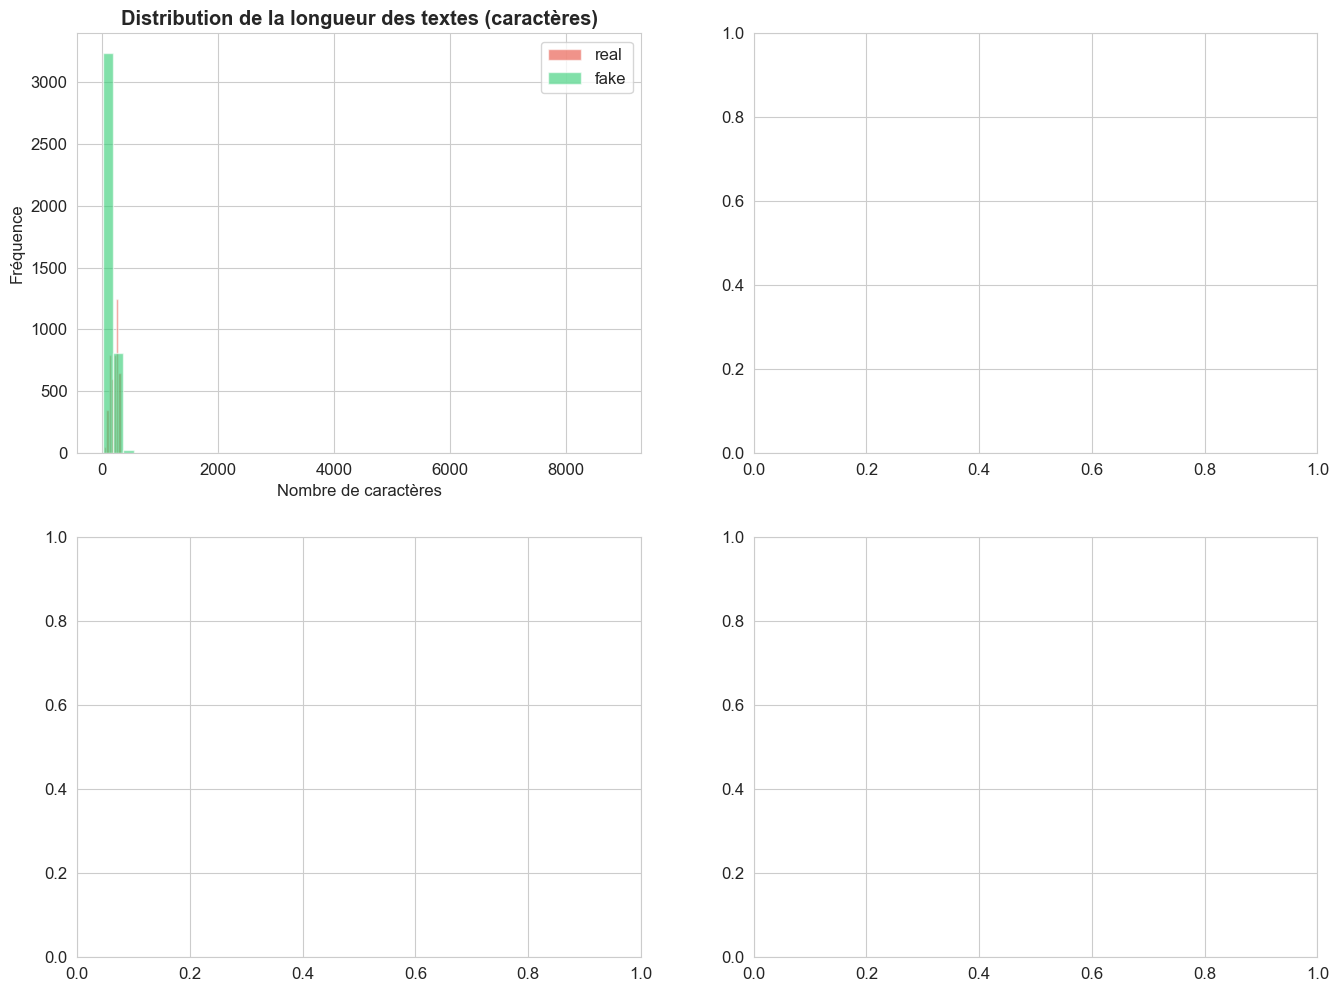

In [18]:
# Visualisation de la distribution des longueurs
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogramme longueur en caractères
for cls, color in zip(df[label_col].unique(), colors):
    subset = df[df[label_col] == cls]
    axes[0, 0].hist(subset['text_length'], bins=50, alpha=0.6, label=cls, color=color)
axes[0, 0].set_title('Distribution de la longueur des textes (caractères)', fontweight='bold')
axes[0, 0].set_xlabel('Nombre de caractères')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].legend()

In [19]:
# Histogramme nombre de mots
for cls, color in zip(df[label_col].unique(), colors):
    subset = df[df[label_col] == cls]
    axes[0, 1].hist(subset['word_count'], bins=50, alpha=0.6, label=cls, color=color)
axes[0, 1].set_title('Distribution du nombre de mots', fontweight='bold')
axes[0, 1].set_xlabel('Nombre de mots')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].legend()

In [20]:
# Boxplot longueur
sns.boxplot(data=df, x=label_col, y='text_length', palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('Boxplot de la longueur des textes', fontweight='bold')
axes[1, 0].set_xlabel('Classe')
axes[1, 0].set_ylabel('Nombre de caractères')

# Boxplot nombre de mots
sns.boxplot(data=df, x=label_col, y='word_count', palette=colors, ax=axes[1, 1])
axes[1, 1].set_title('Boxplot du nombre de mots', fontweight='bold')
axes[1, 1].set_xlabel('Classe')
axes[1, 1].set_ylabel('Nombre de mots')

plt.tight_layout()
plt.savefig('../reports/figures/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

## 1.7 Analyse de la fréquence des mots

Analysons les **30 mots les plus fréquents** dans chaque classe (après suppression des stopwords anglais).

In [21]:
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=30):
    """Extraire les n mots les plus fréquents (hors stopwords)."""
    all_words = []
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        words = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

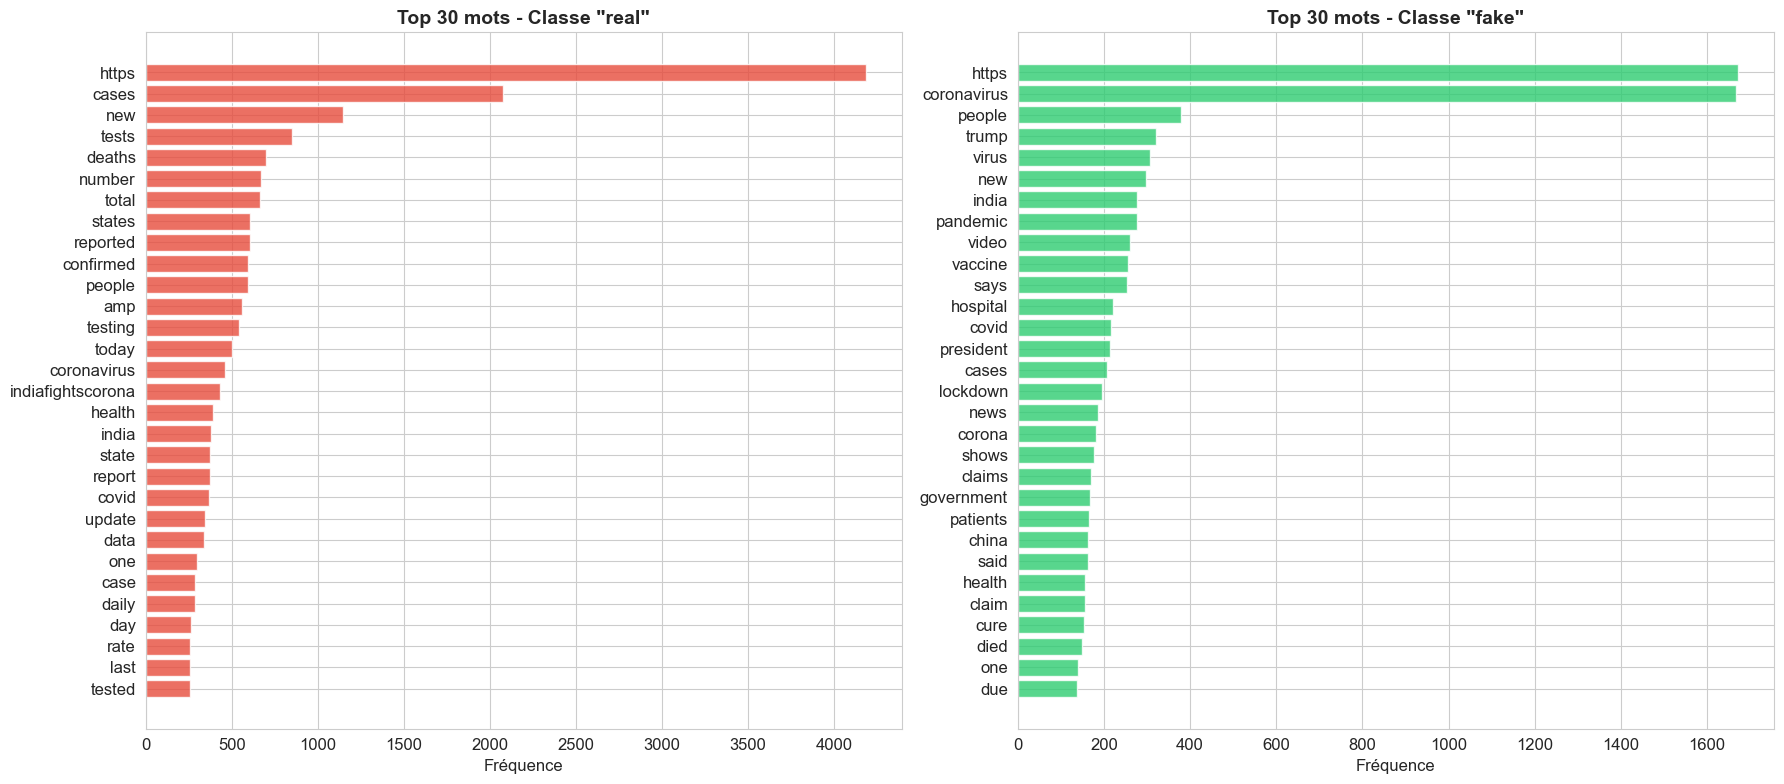

In [22]:
# Top 30 mots par classe
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, (cls, color) in enumerate(zip(df[label_col].unique(), colors)):
    subset = df[df[label_col] == cls]
    top_words = get_top_words(subset[text_col], n=30)
    
    words, counts = zip(*top_words)
    axes[idx].barh(range(len(words)), counts, color=color, alpha=0.8)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 30 mots - Classe "{cls}"', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('../reports/figures/top_words_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.8 Nuages de mots (WordCloud)

Générons des nuages de mots pour visualiser les termes dominants dans chaque classe.

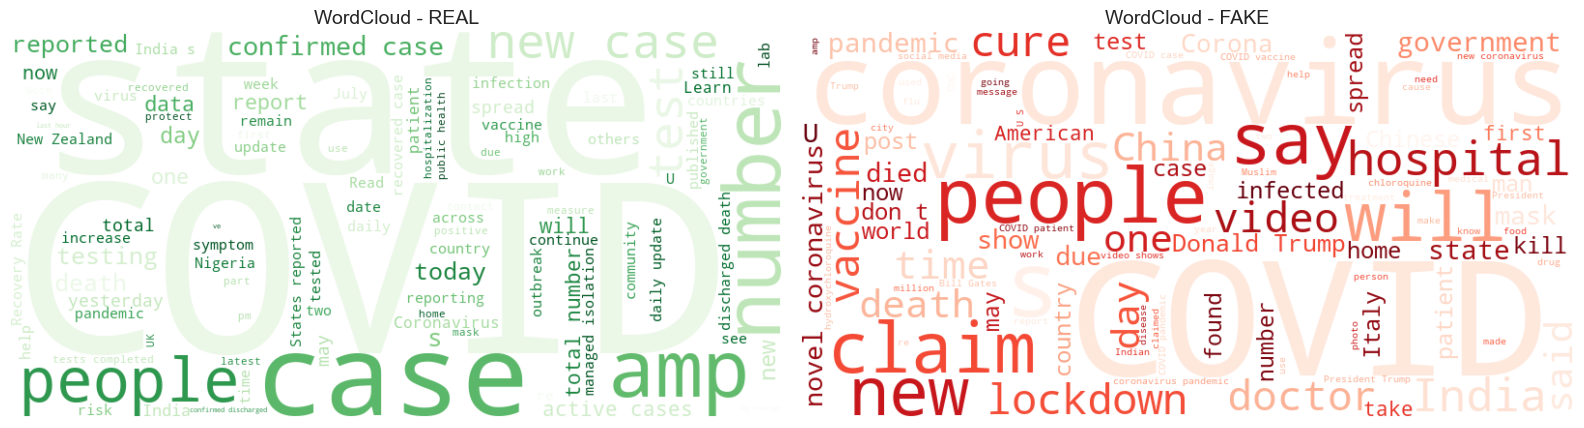

In [23]:
from wordcloud import WordCloud, STOPWORDS
import re

classes_to_plot = ["real", "fake"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, cls in enumerate(classes_to_plot):
    subset = df[df[label_col] == cls]
    if len(subset) == 0:
        continue
    text_combined = " ".join(subset[text_col].astype(str).values)
    text_combined = re.sub(r"http\S+|@\S+|#\S+|RT", "", text_combined)
    text_combined = re.sub(r"[^a-zA-Z\s]", " ", text_combined)
    colormap = "Greens" if cls == "real" else "Reds"
    if len(text_combined.strip()) > 0:
        wc = WordCloud(width=800, height=400, max_words=100,
                       background_color="white", colormap=colormap,
                       stopwords=STOPWORDS, random_state=42
                       ).generate(text_combined)
        axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"WordCloud - {cls.upper()}", fontsize=14)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()


## 1.9 Analyse des bigrammes et trigrammes

Les n-grammes permettent de capturer les associations de mots fréquentes dans chaque classe.

In [24]:
def get_top_ngrams(texts, n=2, top_k=20):
    """Extraire les top_k n-grammes les plus fréquents."""
    all_ngrams = []
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
        all_ngrams.extend(list(ngrams(tokens, n)))
    return Counter(all_ngrams).most_common(top_k)

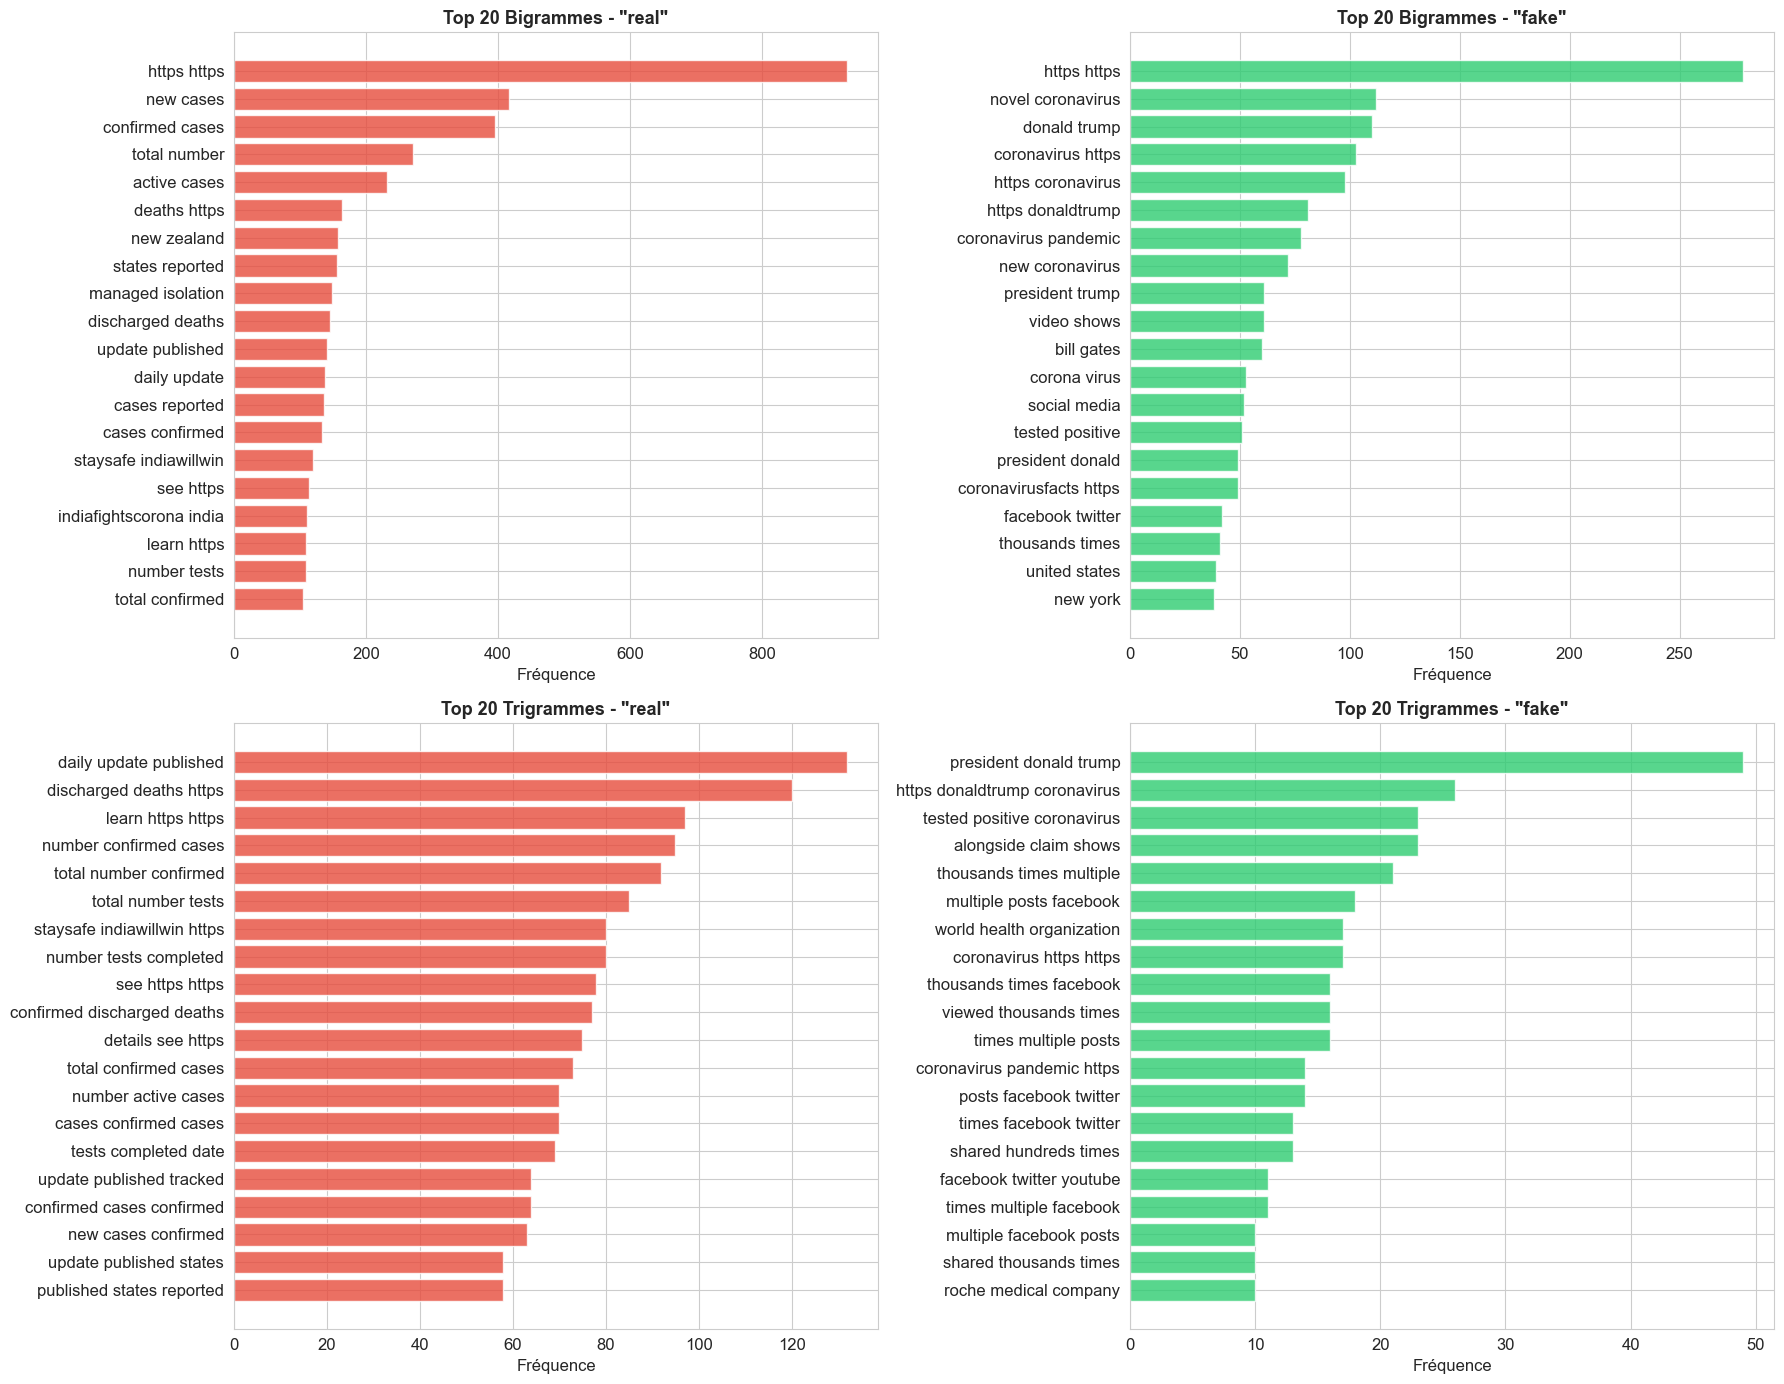

In [25]:
# Bigrammes
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for idx, (cls, color) in enumerate(zip(df[label_col].unique(), colors)):
    subset = df[df[label_col] == cls]
    
    # Bigrammes
    bigrams = get_top_ngrams(subset[text_col], n=2, top_k=20)
    if bigrams:
        labels_bi, counts_bi = zip(*[(f'{b[0]} {b[1]}', c) for b, c in bigrams])
        axes[0, idx].barh(range(len(labels_bi)), counts_bi, color=color, alpha=0.8)
        axes[0, idx].set_yticks(range(len(labels_bi)))
        axes[0, idx].set_yticklabels(labels_bi)
        axes[0, idx].invert_yaxis()
        axes[0, idx].set_title(f'Top 20 Bigrammes - "{cls}"', fontsize=13, fontweight='bold')
        axes[0, idx].set_xlabel('Fréquence')
    
    # Trigrammes
    trigrams = get_top_ngrams(subset[text_col], n=3, top_k=20)
    if trigrams:
        labels_tri, counts_tri = zip(*[(f'{t[0]} {t[1]} {t[2]}', c) for t, c in trigrams])
        axes[1, idx].barh(range(len(labels_tri)), counts_tri, color=color, alpha=0.8)
        axes[1, idx].set_yticks(range(len(labels_tri)))
        axes[1, idx].set_yticklabels(labels_tri)
        axes[1, idx].invert_yaxis()
        axes[1, idx].set_title(f'Top 20 Trigrammes - "{cls}"', fontsize=13, fontweight='bold')
        axes[1, idx].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('../reports/figures/ngrams_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.10 Tests statistiques

Vérifions s'il existe une différence statistiquement significative dans la longueur des textes entre les classes.

In [26]:
# Séparer les classes
classes = df[label_col].unique()
group1 = df[df[label_col] == classes[0]]['text_length']
group2 = df[df[label_col] == classes[1]]['text_length']

print("=" * 60)
print("TESTS STATISTIQUES")
print("=" * 60)

TESTS STATISTIQUES


In [27]:
# Test de normalité (Shapiro-Wilk sur un échantillon)
sample_size = min(5000, len(group1), len(group2))
stat1, p1 = stats.shapiro(group1.sample(min(sample_size, len(group1)), random_state=42))
stat2, p2 = stats.shapiro(group2.sample(min(sample_size, len(group2)), random_state=42))
print(f"\nTest de Shapiro-Wilk (normalité) :")
print(f"  {classes[0]}: stat={stat1:.4f}, p-value={p1:.6f}")
print(f"  {classes[1]}: stat={stat2:.4f}, p-value={p2:.6f}")


Test de Shapiro-Wilk (normalité) :
  real: stat=0.8179, p-value=0.000000
  fake: stat=0.2427, p-value=0.000000


In [28]:
# Test de Mann-Whitney U (non paramétrique)
u_stat, u_pvalue = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"\nTest de Mann-Whitney U :")
print(f"  U-statistic = {u_stat:.2f}")
print(f"  p-value = {u_pvalue:.6e}")
if u_pvalue < 0.05:
    print("  => Différence SIGNIFICATIVE (p < 0.05)")
else:
    print("  => Différence NON significative (p >= 0.05)")


Test de Mann-Whitney U :
  U-statistic = 14318637.00
  p-value = 0.000000e+00
  => Différence SIGNIFICATIVE (p < 0.05)


In [29]:
# Test t de Welch
t_stat, t_pvalue = stats.ttest_ind(group1, group2, equal_var=False)
print(f"\nTest t de Welch :")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {t_pvalue:.6e}")

# Taille de l'effet (Cohen's d)
cohens_d = (group1.mean() - group2.mean()) / np.sqrt((group1.std()**2 + group2.std()**2) / 2)
print(f"\nTaille de l'effet (Cohen's d) : {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print("  => Effet négligeable")
elif abs(cohens_d) < 0.5:
    print("  => Effet faible")
elif abs(cohens_d) < 0.8:
    print("  => Effet moyen")
else:
    print("  => Effet fort")


Test t de Welch :
  t-statistic = 24.0500
  p-value = 2.462239e-121

Taille de l'effet (Cohen's d) : 0.5292
  => Effet moyen


## 1.11 Échantillons de textes par classe

Examinons quelques exemples de textes dans chaque classe pour comprendre les différences qualitatives.

In [30]:
for cls in df[label_col].unique():
    print("=" * 60)
    print(f"EXEMPLES DE LA CLASSE : {cls.upper()}")
    print("=" * 60)
    samples = df[df[label_col] == cls].sample(3, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        text = str(row[text_col])
        # Tronquer si trop long
        display_text = text[:500] + '...' if len(text) > 500 else text
        print(f"\n--- Exemple {i} (longueur: {len(text)} caractères) ---")
        print(display_text)
    print()

EXEMPLES DE LA CLASSE : REAL

--- Exemple 1 (longueur: 213 caractères) ---
Most of you know this by now but there is a very strong weekend effect that hits on Sundays and Mondays especially in the reporting of COVID-19 deaths. Sundays are highlighted in red below. https://t.co/fpaDhxolj0

--- Exemple 2 (longueur: 139 caractères) ---
RT @PIB_India: UPDATE on #COVID19 118 laboratories have been included in the @ICMRDELHI network of COVID-19 testing with a capacity to tes…

--- Exemple 3 (longueur: 110 caractères) ---
Little chance we will see a coronavirus vaccine before November @AmerMedicalAssn says. https://t.co/fMeO2Bn3MA

EXEMPLES DE LA CLASSE : FAKE

--- Exemple 1 (longueur: 113 caractères) ---
An Instagram post is claiming Covid-19 tests tainted with coronavirus have been in circulation for "many months".

--- Exemple 2 (longueur: 91 caractères) ---
Florida May Have To Close https://t.co/PJikoQH1mT #coronavirus #florida #hurricane #tsunami

--- Exemple 3 (longueur: 113 caractères)

## 1.12 Résumé des observations clés

### Principales conclusions de l'analyse exploratoire :

1. **Taille du dataset** : Le dataset contient environ 10 700 articles/posts sur le COVID-19, répartis en deux classes (fake/real).

2. **Équilibre des classes** : Il faut vérifier si le dataset est équilibré ou déséquilibré entre les deux classes. Un déséquilibre pourrait nécessiter des techniques spécifiques (surreprésentation, sous-représentation, ou métriques adaptées).

3. **Longueur des textes** : Les différences de longueur entre les classes fake et real peuvent servir de feature discriminante.

4. **Mots caractéristiques** : Certains mots ou expressions sont plus fréquents dans une classe que dans l'autre, ce qui est encourageant pour la classification.

5. **Qualité des données** : L'analyse des valeurs manquantes et des doublons nous permet de planifier le prétraitement nécessaire.

### Prochaines étapes :
- Prétraitement des textes (nettoyage, normalisation)
- Extraction de features linguistiques
- Modélisation avec des approches baseline (TF-IDF + ML) puis avancées (BERT)

In [31]:
# Nettoyage des colonnes temporaires
cols_to_drop = ['text_length', 'word_count', 'avg_word_length']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Analyse exploratoire terminée.")
print(f"Le dataset est prêt pour le prétraitement (notebook 02_preprocessing).")

Analyse exploratoire terminée.
Le dataset est prêt pour le prétraitement (notebook 02_preprocessing).
